In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import joblib

In [2]:
df = pd.read_csv("../Datasets/anemia.csv")

df.head()

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
0,1,14.9,22.7,29.1,83.7,0
1,0,15.9,25.4,28.3,72.0,0
2,0,9.0,21.5,29.6,71.2,1
3,0,14.9,16.0,31.4,87.5,0
4,1,14.7,22.0,28.2,99.5,0


In [3]:
df.shape

(1421, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      1421 non-null   int64  
 1   Hemoglobin  1421 non-null   float64
 2   MCH         1421 non-null   float64
 3   MCHC        1421 non-null   float64
 4   MCV         1421 non-null   float64
 5   Result      1421 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 66.7 KB


In [5]:
df.describe()

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
count,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000
mean,0.520760,13.412738,22.905630,30.251232,85.523786,0.436312
std,0.499745,1.974546,3.969375,1.400898,9.636701,0.496102
min,0.000000,6.600000,16.000000,27.800000,69.400000,0.000000
25%,0.000000,11.700000,19.400000,29.000000,77.300000,0.000000
50%,1.000000,13.200000,22.700000,30.400000,85.300000,0.000000
75%,1.000000,15.000000,26.200000,31.400000,94.200000,1.000000
max,1.000000,16.900000,30.000000,32.500000,101.600000,1.000000


In [6]:
missing = pd.DataFrame({
    "Missing":df.isnull().sum(),
    "Percent":round(df.isnull().mean()*100,2)
})

missing

,Missing,Percent
Gender,0,0.0
Hemoglobin,0,0.0
MCH,0,0.0
MCHC,0,0.0
MCV,0,0.0
Result,0,0.0


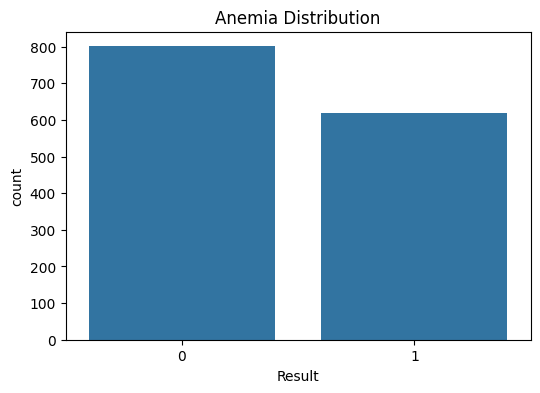

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x='Result',data=df)

plt.title("Anemia Distribution")

plt.show()

In [8]:
df['Result'].value_counts()

Result
0    801
1    620
Name: count, dtype: int64

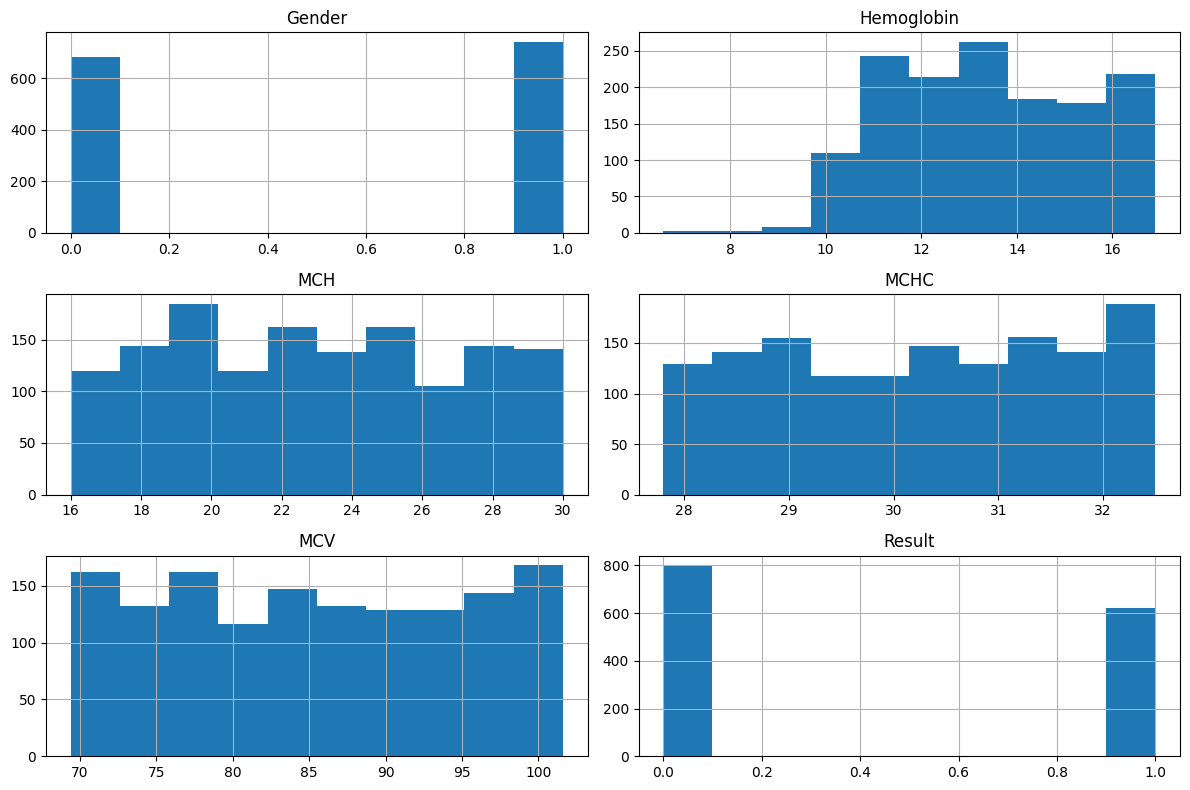

In [9]:
df.hist(figsize=(12,8))

plt.tight_layout()

plt.show()

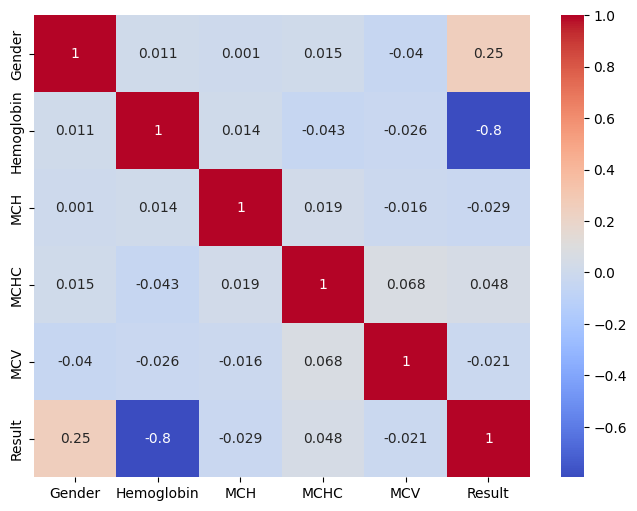

In [10]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),annot=True,cmap='coolwarm')

plt.show()

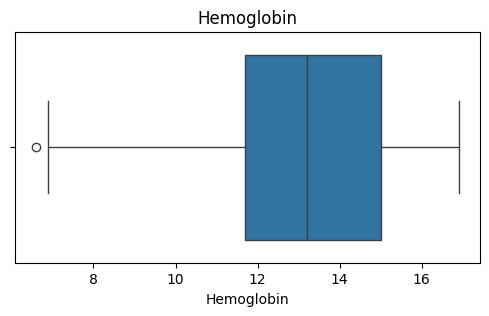

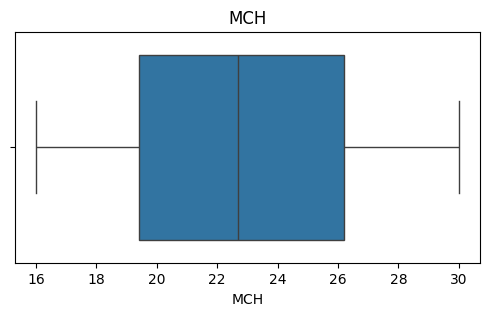

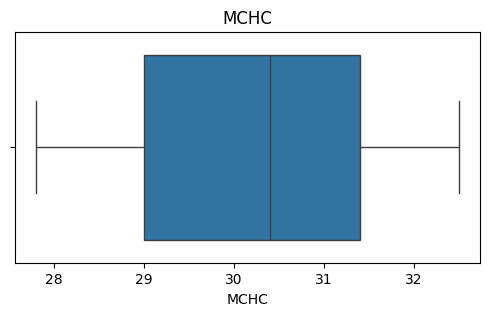

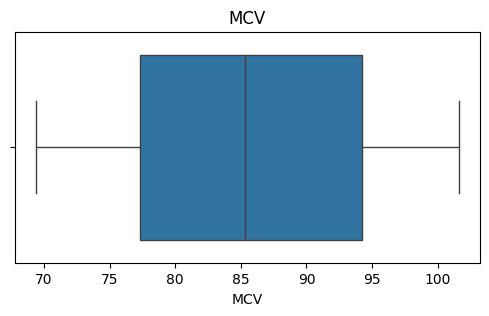

In [11]:
for col in ['Hemoglobin','MCH','MCHC','MCV']:
    
    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [12]:
X = df.drop('Result',axis=1)
y = df['Result']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [14]:
preprocessor = ColumnTransformer([('num',StandardScaler(),X.columns)])

In [15]:
lr_pipeline = Pipeline([('preprocessor', preprocessor),('model',LogisticRegression(max_iter=3000))])

lr_pipeline.fit(X_train,y_train)

pred_lr = lr_pipeline.predict(X_test)

lr_acc = accuracy_score(y_test,pred_lr)

print("Accuracy:", lr_acc)

Accuracy: 0.9894736842105263


In [16]:
rf_pipeline = Pipeline([('preprocessor', preprocessor),('model',RandomForestClassifier(n_estimators=300,random_state=42))])

rf_pipeline.fit(X_train,y_train)

pred_rf = rf_pipeline.predict(X_test)

rf_acc = accuracy_score(y_test,pred_rf)

print("Accuracy:", rf_acc)

Accuracy: 1.0


In [17]:
xgb_pipeline = Pipeline([('preprocessor', preprocessor),('model',XGBClassifier(n_estimators=500,max_depth=4,learning_rate=0.03,random_state=42,))])

xgb_pipeline.fit(X_train,y_train)

pred_xgb = xgb_pipeline.predict(X_test)

xgb_acc = accuracy_score(y_test,pred_xgb)

print("Accuracy:", xgb_acc)

Accuracy: 1.0


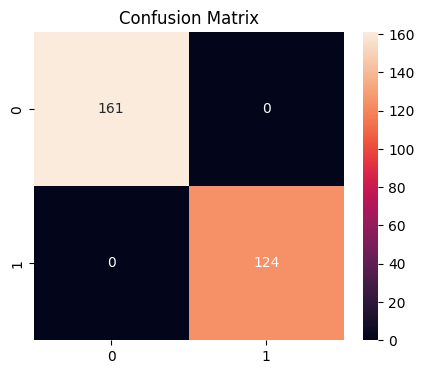

In [18]:
cm = confusion_matrix(y_test,pred_xgb)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt='d')

plt.title("Confusion Matrix")

plt.show()

In [20]:
results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest","XGBoost"],
    "Accuracy":[lr_acc,rf_acc,xgb_acc]
})

results.sort_values(by='Accuracy',ascending=False)

,Model,Accuracy
1,Random Forest,1.000000
2,XGBoost,1.000000
0,Logistic Regression,0.989474


In [21]:
joblib.dump(xgb_pipeline,"anemia_model.pkl")

['anemia_model.pkl']